# Практическая работа №2 "Создание конкуртной нейронной сети"

**Цель работы:** изучить топологию и алгоритм функционирования конкурентной нейронной сети.

## Теоретическая часть

**Конкурентная нейронная сеть** относится к самоорганизующимся нейронным сетям и обучается **без учителя**. Такие сети способны адаптироваться к входным данным, используя внутренние зависимости в обучающей выборке.

Конкурентные сети применяются для:
- кластеризации данных;
- выделения признаков;
- сжатия представления данных.

Конкурентная нейронная сеть является простейшей самоорганизующейся нейронной сетью. Первый слой сети выполняет распределение входного сигнала, а нейроны второго слоя конкурируют между собой за право стать активными.

Пусть входной вектор имеет вид:

$x = (x_1, x_2, \dots, x_i, \dots, x_n)$

Тогда выход $j$-го нейрона определяется скалярным произведением входного вектора и вектора весов:

$y_j = \sum_{i=1}^{n} w_{ij} x_i = |w^j| \, |x| \cos(\alpha)$

где:  
- $x$ — входной вектор;  
- $w^j = (w_{1j}, w_{2j}, \dots, w_{ij}, \dots, w_{nj})$ — вектор весовых коэффициентов $j$-го нейрона;  
- $|x|$ и $|w^j|$ — модули соответствующих векторов;  
- $\alpha$ — угол между векторами $x$ и $w^j$.

При обучении сети определяется **нейрон-победитель**, для которого значение $y_j$ максимально. После этого веса нейрона-победителя корректируются по правилу:

$w_{ij}(t+1) = w_{ij}(t) + \beta \bigl(x_i - w_{ij}(t)\bigr)$

где $\beta$ — скорость обучения.

Смысл данного правила состоит в том, что вектор весов нейрона-победителя приближается к входному вектору. Это позволяет нейрону лучше распознавать похожие образы при последующих подачах входных данных.

Для повышения устойчивости работы сети удобно использовать **нормированные** входные и весовые векторы. В этом случае выражение для выхода нейрона принимает вид:

$y_j = \sum_{i=1}^{n} w_{ij} x_i = \cos(\alpha)$

Тогда правило корректировки весов можно записать в нормированной форме:

$w_{ij}(t+1) = \frac{w_{ij}(t) + \beta \bigl(x_i - w_{ij}(t)\bigr)}{\left|w^j(t) + \beta \bigl(x - w^j(t)\bigr)\right|}$

Случайная инициализация весов может привести к тому, что некоторые нейроны редко или вообще никогда не будут становиться победителями. Для устранения этого недостатка используется **частотно-зависимое конкурентное обучение**.

В этом случае нейрон-победитель определяется по критерию:

$d_v = \min_j \left( |x - w^j| \, f_j \right)$

где:  
- $|x - w^j|$ — евклидово расстояние между входным вектором и весовым вектором нейрона;  
- $f_j$ — число побед $j$-го нейрона.

Чем больше побед у нейрона, тем меньше его шансы снова стать победителем. Это позволяет более равномерно распределять входные образы между нейронами сети.

Конкурентная сеть разбивает множество входных векторов на кластеры. Все входные образы, которые активируют один и тот же нейрон-победитель, относятся к одному кластеру.


## Порядок выполнения работы

1. Ознакомиться с теоретической частью по конкурентным нейронным сетям.
2. Реализовать конкурентную нейронную сеть в Python в среде Google Colab.
3. Подготовить набор идеальных образов размером $6 \times 6$ в соответствии с вариантом задания.
4. Преобразовать каждый образ в вектор входных данных.
5. Выполнить нормировку входных векторов.
6. Сформировать матрицу весовых коэффициентов и выполнить её нормировку.
7. Обучить сеть по правилу конкурентного обучения с использованием критерия:
   $KRIT_j = f_j \cdot \|X_j^{norm} - W_j^{norm}\|$
8. Определить нейрон-победитель по минимальному значению критерия:
   $K_{min} = p$, если $KRIT_p < KRIT_j$ для всех $j \ne p$
9. После определения победителя увеличить счётчик его побед:
   $f_{K_{min}} = f_{K_{min}} + 1$
10. Выполнить коррекцию весов нейрона-победителя:
$$
\Delta W^{K_{\min}}_{\text{norm}} = \mu \left( X^{K_{\min}}_{\text{norm}} - W^{K_{\min}}_{\text{norm}} \right)
$$
11. Повторять обучение до устойчивого распределения образов по кластерам.
12. Создать зашумлённые тестовые образы с искажением 10%, 20%, 30% и 40%.
13. Подать тестовые образы на вход сети и определить, к какому кластеру они отнесены.
14. Проверить работу сети при числе выходных нейронов, меньшем числа образов.
15. Провести серию экспериментов при разных значениях числа выходных нейронов: `m = 5`, `m = 4`, `m = 3`.
16. Для каждого значения `m` определить, как распределяются по кластерам идеальные и зашумлённые образы.
17. Исследовать влияние скорости обучения, выполнив эксперименты при `h = 0.01`, `h = 0.05`, `h = 0.1`.
18. Для каждого значения `h` сравнить устойчивость распознавания образов при уровнях шума 10%, 20%, 30% и 40%.
19. Сравнить результаты всех проведённых экспериментов и определить, при каких значениях `h` сеть работает наиболее устойчиво.
20. Сделать выводы о способности конкурентной сети выполнять кластеризацию и распознавание зашумлённых образов.

### Таблица вариантов заданий

| № варианта | 1-й класс | 2-й класс | 3-й класс | 4-й класс | 5-й класс |
|---|---|---|---|---|---|
| 1 | 2 | 3 | 4 | 5 | 7 |
| 2 | N | F | I | P | D |
| 3 | ∧ | ∨ | E | C | U |
| 4 | ⊗ | ⊕ | × | ÷ | ± |
| 5 | ≤ | ≥ | ≠ | ≡ | ≈ |
| 6 | L | U | T | O | K |
| 7 | → | ↔ | ← | ↓ | ↲ |
| 8 | L | U | T | O | K |
| 9 | D | R | T | E | W |
| 10 | 5 | 6 | 7 | 8 | 9 |
| 11 | 1 | 3 | 5 | 7 | 9 |
| 12 | 2 | 4 | 6 | 8 | 0 |
| 13 | F | R | H | K | L |
| 14 | J | K | L | R | E |
| 15 | Z | X | B | N | M |
| 16 | + | - | * | / | = |
| 17 | @ | # | % | ^ | & |
| 18 | F | G | H | J | K |
| 19 | W | S | X | E | D |
| 20 | R | X | G | H | J |
| 21 | A | C | E | F | H |
| 22 | O | Q | C | G | D |
| 23 | P | B | R | D | O |
| 24 | X | Y | Z | V | W |
| 25 | M | N | H | K | X |
| 26 | 0 | 1 | 7 | 8 | 9 |
| 27 | 2 | 5 | 6 | 3 | 8 |
| 28 | < | > | = | + | - |
| 29 | * | / | + | = | # |
| 30 | @ | % | & | * | + |
| 31 | A | L | T | V | X |
| 32 | E | F | I | L | T |
| 33 | C | O | U | G | Q |
| 34 | H | K | M | N | W |
| 35 | P | R | F | E | B |
| 36 | J | L | I | T | Y |
| 37 | S | Z | 2 | 5 | 8 |
| 38 | D | O | C | G | 0 |
| 39 | U | V | W | X | Y |
| 40 | A | H | M | T | W |
| 41 | → | ← | ↑ | ↓ | ↔ |
| 42 | + | × | - | ÷ | = |
| 43 | < | ≤ | > | ≥ | = |
| 44 | ( | ) | [ | ] | O |
| 45 | / | \ | X | T | Y |
| 46 | @ | O | Q | C | 0 |
| 47 | # | H | M | N | E |
| 48 | % | X | K | Z | V |
| 49 | ^ | A | V | Y | T |
| 50 | & | 8 | S | 5 | 3 |


## Пример выполнения работы
В данном примере реализуется конкурентная нейронная сеть для распознавания 5 образов размером $6 \times 6$: **L, U, T, O, K**.

Алгоритм выполнения:
1. Задаются идеальные бинарные образы.
2. Для каждого образа создаются зашумлённые версии с искажением 10%, 20%, 30% и 40%.
3. Все изображения преобразуются в векторы длины 36.
4. Выполняется обучение конкурентной нейронной сети.
5. Для каждого входного образа определяется нейрон-победитель.
6. Результаты представляются в виде матрицы кластеров.

В качестве критерия выбора нейрона-победителя используется выражение:

$KRIT_j = f_j \cdot \|X - W_j\|$

где:
- $X$ — входной вектор,
- $W_j$ — вектор весов $j$-го нейрона,
- $f_j$ — число побед $j$-го нейрона.

Победителем считается нейрон, для которого значение критерия минимально.

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math

np.random.seed(42)

# ============================================
# 1. Исходные образы 6x6
# ============================================

L = np.array([
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 1, 1, 1, 1],
    [1, 0, 0, 0, 0, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

U = np.array([
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

T = np.array([
    [0, 0, 0, 0, 0, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 0, 1, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

O = np.array([
    [1, 1, 0, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 0, 0, 1, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

K = np.array([
    [1, 0, 1, 1, 0, 1],
    [1, 0, 1, 0, 1, 1],
    [1, 0, 0, 1, 1, 1],
    [1, 0, 1, 0, 1, 1],
    [1, 0, 1, 1, 0, 1],
    [1, 1, 1, 1, 1, 1]
], dtype=float)

base_images = {
    "L": L,
    "U": U,
    "T": T,
    "O": O,
    "K": K
}

In [12]:
# ============================================
# 2. Вспомогательные функции
# ============================================

def to_vector(img):
    return img.T.reshape(-1).astype(float)

def normalize_vector(x):
    norm = np.linalg.norm(x)
    return x / norm if norm != 0 else x

def add_noise(img, flips):
    noisy = img.copy().reshape(-1)
    idx = np.random.choice(len(noisy), size=flips, replace=False)
    noisy[idx] = 1 - noisy[idx]
    return noisy.reshape(img.shape)

def show_images(images_dict, title):
    fig, axes = plt.subplots(1, len(images_dict), figsize=(14, 3))
    fig.suptitle(title, fontsize=14)
    for ax, (name, img) in zip(axes, images_dict.items()):
        ax.imshow(img, cmap="gray_r")
        ax.set_title(name)
        ax.axis("off")
    plt.show()

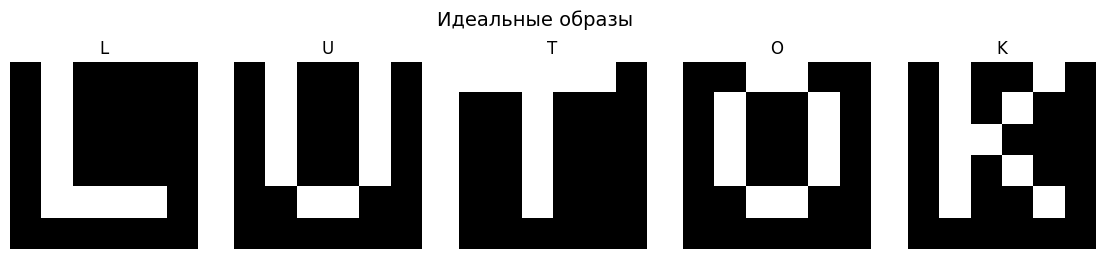

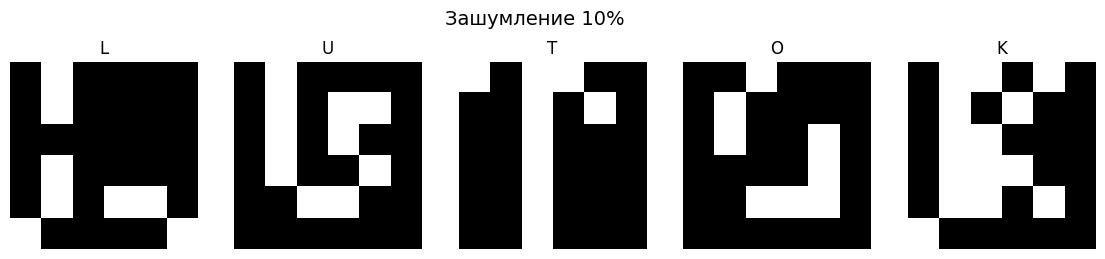

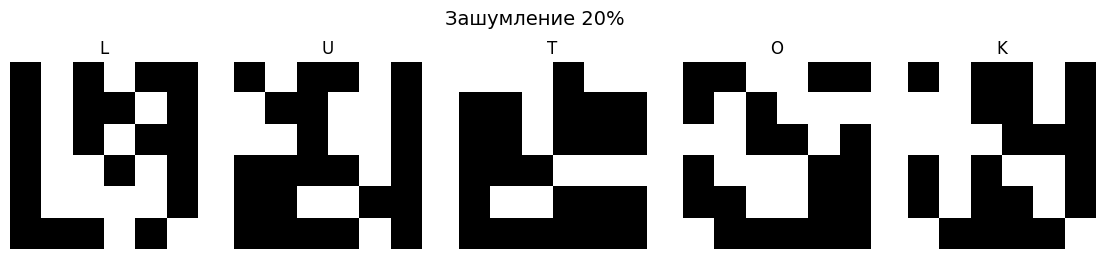

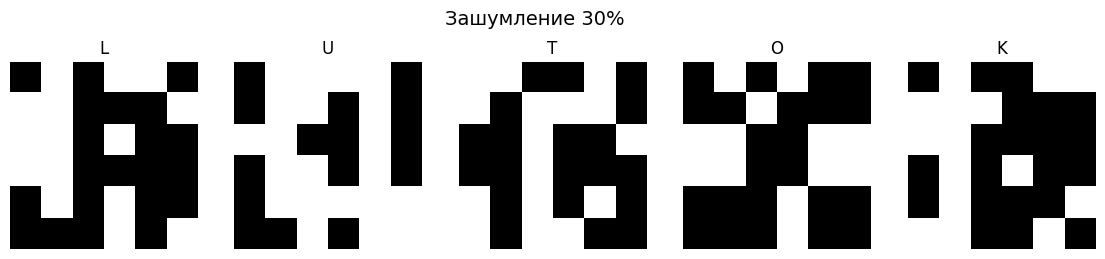

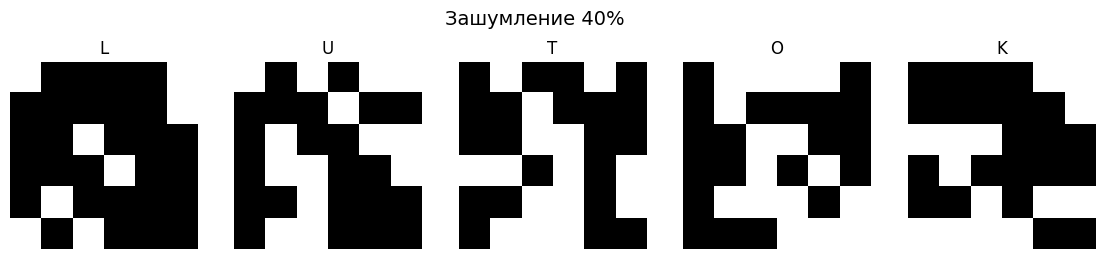

In [13]:
# ============================================
# 3. Создание зашумленных образов
# ============================================

noise_levels = {
    "0%": 0,
    "10%": 4,
    "20%": 7,
    "30%": 11,
    "40%": 14
}

all_images = {}
for noise_name, flips in noise_levels.items():
    all_images[noise_name] = {}
    for label, img in base_images.items():
        if flips == 0:
            all_images[noise_name][label] = img.copy()
        else:
            all_images[noise_name][label] = add_noise(img, flips)

show_images(base_images, "Идеальные образы")
show_images(all_images["10%"], "Зашумление 10%")
show_images(all_images["20%"], "Зашумление 20%")
show_images(all_images["30%"], "Зашумление 30%")
show_images(all_images["40%"], "Зашумление 40%")

In [ ]:
# ============================================
# 4. Подготовка обучающей выборки
# ============================================

train_labels = list(base_images.keys())
X_train = np.array([normalize_vector(to_vector(base_images[label])) for label in train_labels])

# ============================================
# 5. Обучение конкурентной сети
# ============================================

def train_competitive_network(X, m=5, h=0.05, epochs=30, seed=42):
    np.random.seed(seed)
    n = X.shape[1]

    W = np.random.rand(n, m) * 2 - 1
    for j in range(m):
        W[:, j] = normalize_vector(W[:, j])

    f = np.ones(m)

    for _ in range(epochs):
        for x in X:
            krit = [0.0 for _ in range(m)]

            # вычисление KRIT_j
            for j in range(m):
                s = 0.0
                for i in range(n):
                    s += (x[i] - W[i][j]) ** 2
                krit[j] = math.sqrt(s) * f[j]

            # поиск нейрона-победителя
            winner = 0
            min_value = krit[0]
            for j in range(1, m):
                if krit[j] < min_value:
                    min_value = krit[j]
                    winner = j

            # увеличение счетчика побед
            f[winner] += 1

            # коррекция весов нейрона-победителя
            for i in range(n):
                W[i][winner] = W[i][winner] + h * (x[i] - W[i][winner])

    return W, f

In [15]:
# ============================================
# 6. Классификация образов
# ============================================

def predict_cluster(x, W, f):
    x = normalize_vector(x)
    krit = np.array([np.linalg.norm(x - W[:, j]) * f[j] for j in range(W.shape[1])])
    return np.argmin(krit) + 1  # нумерация с 1

def evaluate_network(all_images, W, f):
    labels = ["L", "U", "T", "O", "K"]
    levels = ["0%", "10%", "20%", "30%", "40%"]
    result = np.zeros((5, 5), dtype=int)

    for i, label in enumerate(labels):
        for j, level in enumerate(levels):
            x = to_vector(all_images[level][label])
            result[i, j] = predict_cluster(x, W, f)

    return result

In [16]:
# ============================================
# 7. Эксперимент 1: m = 5
# ============================================

W5, f5 = train_competitive_network(X_train, m=5, h=0.05, epochs=30, seed=42)
REZ5 = evaluate_network(all_images, W5, f5)

print("Результат для m = 5")
print("Строки: L, U, T, O, K")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ5)

Результат для m = 5
Строки: L, U, T, O, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[2 2 2 2 5]
 [4 4 4 4 5]
 [5 5 5 5 4]
 [1 2 1 1 5]
 [3 3 3 2 3]]


In [17]:
# ============================================
# 8. Эксперимент 2: m = 3
# ============================================

W3, f3 = train_competitive_network(X_train, m=3, h=0.05, epochs=30, seed=42)
REZ3 = evaluate_network(all_images, W3, f3)

print("\nРезультат для m = 3")
print("Строки: L, U, T, O, K")
print("Столбцы: 0%, 10%, 20%, 30%, 40%")
print(REZ3)


Результат для m = 3
Строки: L, U, T, O, K
Столбцы: 0%, 10%, 20%, 30%, 40%
[[1 1 1 1 1]
 [3 1 1 1 1]
 [2 2 1 1 1]
 [3 3 1 1 1]
 [1 1 1 1 1]]


**Выводы:**

## Контрольные вопросы

1. В чём заключается смысл самообучения нейронной сети?
2. Как выполняется обучение конкурентной нейронной сети?
3. Каким образом определяется нейрон-победитель в конкурентной нейронной сети?
4. Где используются самоорганизующиеся нейронные сети?
5. Каковы основные достоинства и недостатки конкурентной нейронной сети?